In [1]:
# necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.linear_model import ElasticNetCV
# from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [22]:
# working directory
os.chdir("i:/Hu Lab/Sophie/1. Cell death/visium image manual spot selection/20260413_final_merge/data")

# my dataset & then setting predictors and response variable
df = pd.read_csv("0511iso_sig_means.csv")
# df = pd.read_csv("0511pd_sig_means.csv")

gene_cols = df.columns[11:61]
X = df[gene_cols]
y = df["prop_dying"]

In [23]:
model = Pipeline([
    ("scaler", StandardScaler()),            # transform each feature to have same scale
    ("enet", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],  # mixing parameter, smaller is more lasso (less important = 0), 
                                             # larger is more ridge (shrinking less important and keeping ALL features)
        alphas=None,
        cv=5,              # trains on 4 folds, tests on 1 fold & repeat for all 
        max_iter=10000,
        n_jobs=-1
    ))
])

In [24]:
model.fit(X, y)

c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.770e-03, tolerance: 7.563e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('enet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.3, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",None


In [25]:
enet = model.named_steps["enet"]

coeffs = enet.coef_
intercept = enet.intercept_

for name, coef in zip(gene_cols, coeffs):
    print(f"{name}: {coef:.4f}")

Prolif Oaf Tumor: 0.5752
Nonprolif Wfdc2 Tumor: -0.2556
Prolif Wfdc2 Tumor: 0.2847
Nonprolif Oaf Tumor: 0.0000
Fibroblasts: 0.0364
Endothelial: 0.0000
Mural Cells: 0.0000
MHCII Hi Macs: -0.1583
CD4 T: -0.2853
Monocytes: -0.0899
Exhausted CD8 T: -0.0000
Cd81 Hi Macs: 0.0047
Lyve1 Macs: 0.2418
Naive/Stem CD8 T: -0.0406
Doublets: -0.0862
Prolif Macs: -0.2226
Arg1 Hi Macs: -0.0000
Ear2 Monocytes: -0.0006
cDC2: 0.0164
cDC3: 0.0008
NK: 0.0974
Neutrophils: 0.0000
Treg: -0.0000
pDC: -0.1255
cDC1: -0.0000


In [26]:
# checking characteristics
enet.l1_ratio_ # returns % lasso. if it's smaller --> more correlated genes togetther
# enet.alpha_

np.float64(0.3)

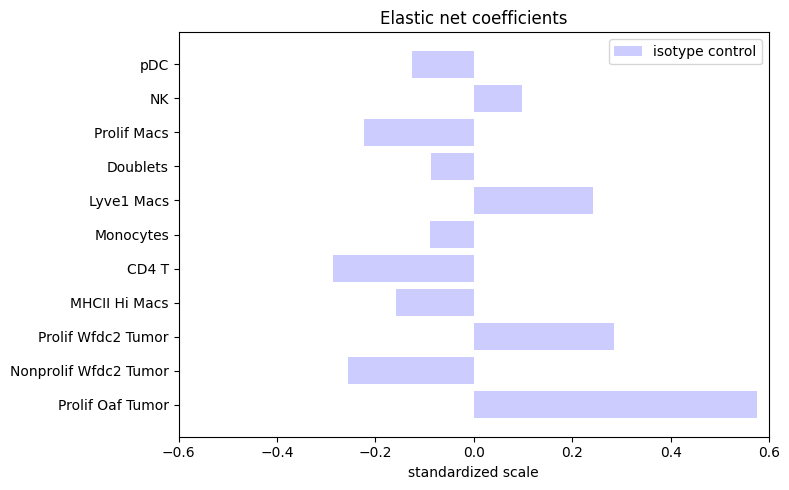

In [28]:
# barcharts
mask = abs(coeffs) > 0.05

coeffs_nz = coeffs[mask]
gene_cols_nz = gene_cols[mask]

iso7_df = pd.Series(coeffs_nz, index=gene_cols_nz) # obtained from running it again & changing dataset.
                                                   # renamed vars to maintain previous
# pd1_df = pd.Series(coeffs_nz, index=gene_cols_nz)                                        

# Plotting
plt.figure(figsize=(8, 5))
plt.barh(gene_cols_nz, iso7_df, alpha=0.2, label='isotype control', color='blue')
# plt.barh(gene_cols_nz, pd1_df, alpha=0.2, label='anti-PD1-treated', color='red')

# Customization
plt.legend()
plt.xlabel("standardized scale")
plt.xlim(-0.6, 0.6)
plt.title("Elastic net coefficients")
#plt.tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate

# what is this model's capability to distinguish these programs as predictors of dying areas?
scores = cross_validate(
    model, X, y,
    cv=5,
    scoring=["r2", "neg_mean_squared_error"]
)

print(scores["test_r2"].mean())
print(scores["test_neg_mean_squared_error"].mean())

print(scores["test_r2"].mean())
print(scores["test_roc_auc"].mean())

c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.512e-02, tolerance: 5.889e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\saliu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 

AttributeError: Pipeline has none of the following attributes: decision_function, predict_proba.